# Análise Exploratória de Dados (EDA) — Telco Customer Churn

Este notebook documenta a exploração do dataset de uma operadora de telecomunicações.  
O objetivo é entender os dados antes de construir qualquer modelo.

A EDA responde às perguntas:
- Como os dados estão estruturados?
- Os dados têm problemas de qualidade?
- Quais variáveis parecem relevantes para prever churn?
- O problema é desbalanceado?

> **Dataset:** Telco Customer Churn (IBM) — 7.043 clientes, 33 colunas.

---
## 1. Carregamento e Visão Geral

In [1]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s — %(message)s')
logger = logging.getLogger(__name__)

DATA_PATH = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_PATH)
logger.info('Dataset carregado: %s', df.shape)

2026-04-17 22:59:45,959 INFO — Dataset carregado: (7043, 33)


In [2]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,...,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,...,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,...,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,...,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293","34,039224","-118,266293",Male,...,Month-to-month,Yes,Bank transfer (automatic),"103,7","5036,3",Yes,1,89,5340,Competitor had better devices


**Primeiras observações:**
- `CustomerID` é um identificador único — não será usado no modelo
- Existem muitas colunas categóricas (Yes/No, tipo de serviço...)
- `Churn Label` é o nosso **target** (Yes = cancelou, No = ficou)
- `Monthly Charges` e `Total Charges` estão como `object` — precisam de conversão
- Colunas geográficas (`Country`, `State`, `City`, `Zip Code`, `Lat Long`) e de negócio (`Churn Score`, `CLTV`, `Churn Reason`) serão removidas do modelo

In [3]:
logger.info('Shape: %s', df.shape)
display(df.dtypes.to_frame('dtype'))

2026-04-17 22:59:45,984 INFO — Shape: (7043, 33)


,dtype
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,object
Longitude,object
Gender,object


---
## 2. Qualidade dos Dados

### 2.1 Valores nulos

In [4]:
nulls = df.isnull().sum()
display(nulls[nulls > 0].to_frame('nulls'))

,nulls
Churn Reason,5174


**Resultado:** `Churn Reason` tem 5.174 nulos — esperado, pois só clientes que cancelaram têm motivo registrado. As demais colunas não têm nulos aparentes. Porém, `Monthly Charges` e `Total Charges` estão como `object`, o que pode esconder valores inválidos.

### 2.2 Tratar colunas numéricas (vírgula → ponto e valores inválidos)

In [5]:
for col in ['Monthly Charges', 'Total Charges']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')
    n_nulls = df[col].isnull().sum()
    logger.info('%s — nulos após conversão: %d', col, n_nulls)
    if n_nulls > 0:
        # Clientes com tenure=0 ainda não foram faturados → imputar com 0
        df[col] = df[col].fillna(0)

2026-04-17 22:59:46,014 INFO — Monthly Charges — nulos após conversão: 0


2026-04-17 22:59:46,019 INFO — Total Charges — nulos após conversão: 11


**Descoberta:** `Total Charges` tinha 11 registros com espaço vazio (clientes com `Tenure Months = 0`, ainda não faturados). Imputados com `0` — faz sentido contextualmente.

### 2.3 Linhas duplicadas

In [6]:
logger.info('Linhas duplicadas: %d', df.duplicated().sum())

2026-04-17 22:59:46,035 INFO — Linhas duplicadas: 0


### 2.4 Estatísticas descritivas após limpeza

In [7]:
display(df.describe())

,Count,Zip Code,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


---
## 3. Distribuição do Target: `Churn Label`

O **target** é a variável que queremos prever: `Churn Label`.
- `Yes` → o cliente cancelou o serviço
- `No`  → o cliente permaneceu

Esta análise é crítica: se o target for muito desbalanceado, um modelo que sempre prevê "No" teria alta acurácia — mas seria inútil. Por isso, **acurácia não é uma boa métrica para churn**.

2026-04-17 22:59:46,065 INFO — Distribuição Churn:
Churn Label
No     73.463013
Yes    26.536987


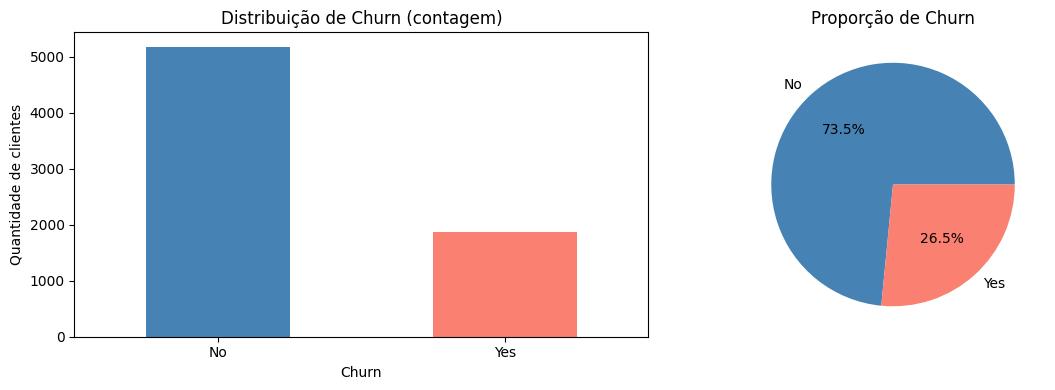

In [8]:
churn_counts = df['Churn Label'].value_counts()
churn_pct = df['Churn Label'].value_counts(normalize=True) * 100
logger.info('Distribuição Churn:\n%s', churn_pct.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Distribuição de Churn (contagem)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Quantidade de clientes')
axes[0].tick_params(axis='x', rotation=0)

churn_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title('Proporção de Churn')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Conclusão: Dataset Desbalanceado

- **~73% dos clientes** não cancelaram (`No`)
- **~27% dos clientes** cancelaram (`Yes`)

Proporção ~3:1. Não é catastrófico, mas precisa de atenção na modelagem.

**Implicações:**
- ❌ Não usar acurácia como métrica principal
- ✅ Usar **Recall** (não deixar churns escaparem) e **F1** como métricas
- ✅ Na MLP PyTorch: `pos_weight ≈ 2.8` na `BCEWithLogitsLoss`
- ✅ Na Regressão Logística: `class_weight='balanced'`

---
## 4. Análise das Features Numéricas

O dataset tem 3 features contínuas:
- **`Tenure Months`**: há quantos meses o cliente está na empresa
- **`Monthly Charges`**: valor mensal da fatura
- **`Total Charges`**: valor total já faturado

### 4.1 Distribuição geral (histogramas)

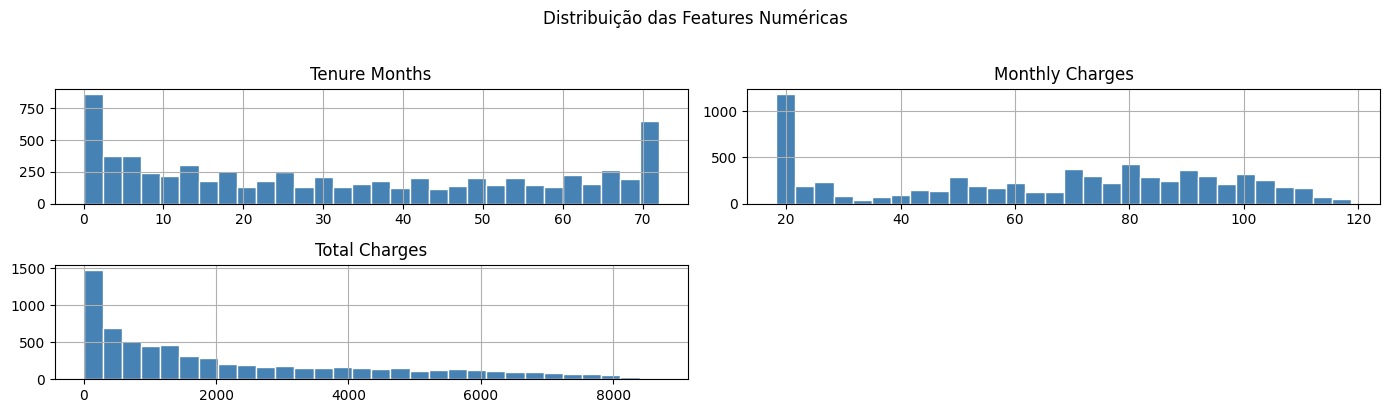

In [9]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

df[num_cols].hist(bins=30, figsize=(14, 4), color='steelblue', edgecolor='white')
plt.suptitle('Distribuição das Features Numéricas', y=1.02)
plt.tight_layout()
plt.show()

**Observações:**
- **`Tenure Months`**: Distribuição bimodal — muitos clientes novos e muitos fiéis, poucos no meio.
- **`Monthly Charges`**: Levemente enviesada à direita. Concentração de planos básicos (~20).
- **`Total Charges`**: Muito enviesada à direita — consequência direta do tenure baixo.

### 4.2 Comparação por Churn (boxplots)

Se as caixas estiverem em posições **muito diferentes** entre `No` e `Yes`, a variável tem **poder preditivo**.

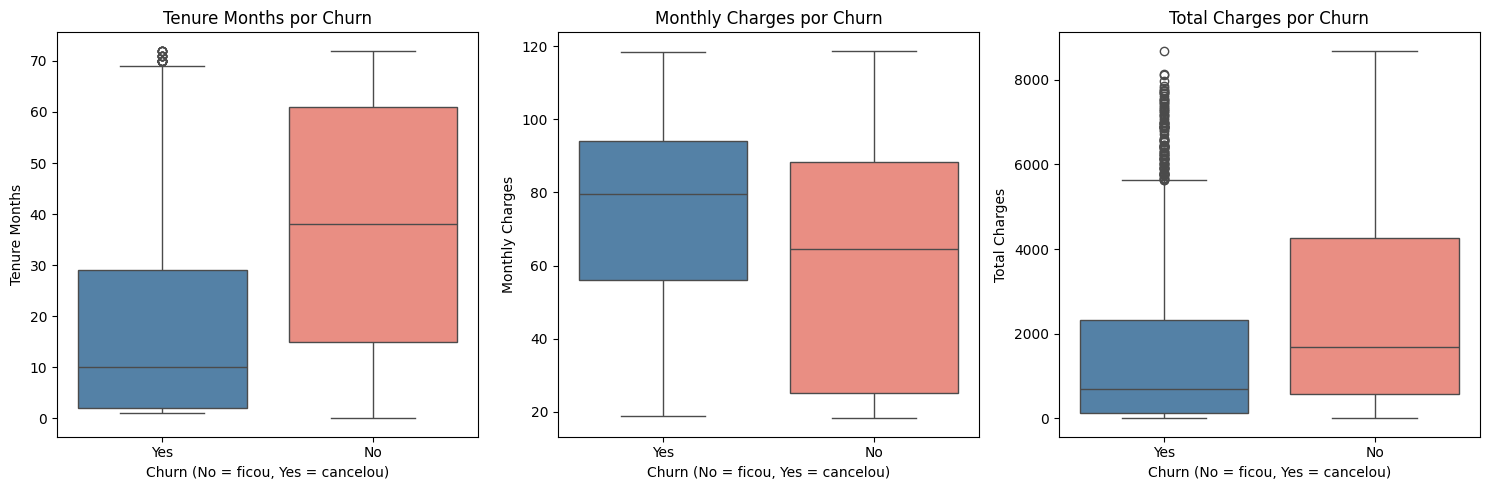

2026-04-17 22:59:46,880 INFO — Mediana de Tenure Months por Churn:
Churn Label
No     38.0
Yes    10.0


2026-04-17 22:59:46,882 INFO — Mediana de Monthly Charges por Churn:
Churn Label
No     64.425
Yes    79.650


2026-04-17 22:59:46,884 INFO — Mediana de Total Charges por Churn:
Churn Label
No     1679.525
Yes     703.550


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Churn Label', y=col, data=df, palette=['steelblue', 'salmon'], ax=ax)
    ax.set_title(f'{col} por Churn')
    ax.set_xlabel('Churn (No = ficou, Yes = cancelou)')

plt.tight_layout()
plt.show()

for col in num_cols:
    logger.info('Mediana de %s por Churn:\n%s', col, df.groupby('Churn Label')[col].median().to_string())

**Resultados:**
- **`Tenure Months`**: Clientes que ficaram têm mediana ~38 meses; churners ~10 meses. **Preditor fortíssimo.**
- **`Monthly Charges`**: Churners pagam mensalidades mais altas — planos caros têm menor percepção de valor.
- **`Total Charges`**: Churners têm total menor — consequência direta do tenure baixo.

---
## 5. Análise das Features Categóricas

Usamos `pd.crosstab(..., normalize='index')` para ver, **dentro de cada categoria**, qual percentual de clientes cancelou.

2026-04-17 22:59:46,898 INFO — Taxa de churn por Contract:
Churn Label       No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


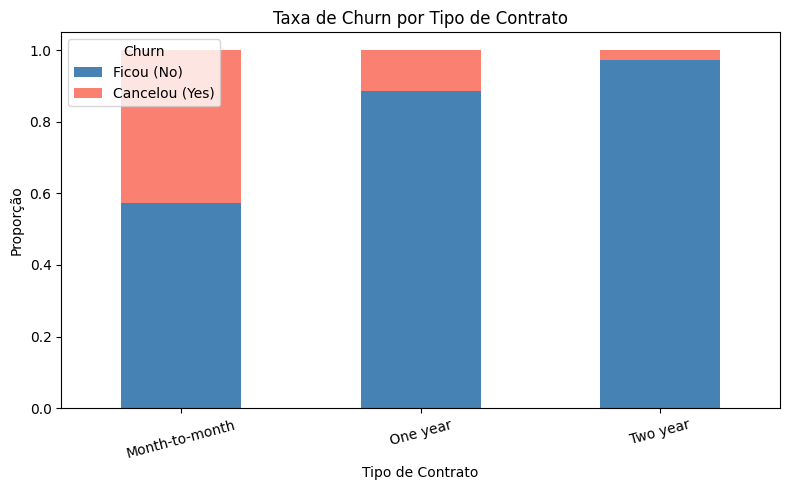

In [11]:
# Contract — hipótese: contratos mensais têm mais churn
ct_contract = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
logger.info('Taxa de churn por Contract:\n%s', (ct_contract * 100).round(1).to_string())

ct_contract.plot(kind='bar', stacked=True, color=['steelblue', 'salmon'], figsize=(8, 5))
plt.title('Taxa de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Proporção')
plt.xticks(rotation=15)
plt.legend(title='Churn', labels=['Ficou (No)', 'Cancelou (Yes)'])
plt.tight_layout()
plt.show()

**Resultado impactante!**
- Contrato **mensal**: ~43% de churn
- Contrato de **1 ano**: ~11% de churn
- Contrato de **2 anos**: apenas ~3% de churn

`Contract` é **o preditor mais forte** do dataset.

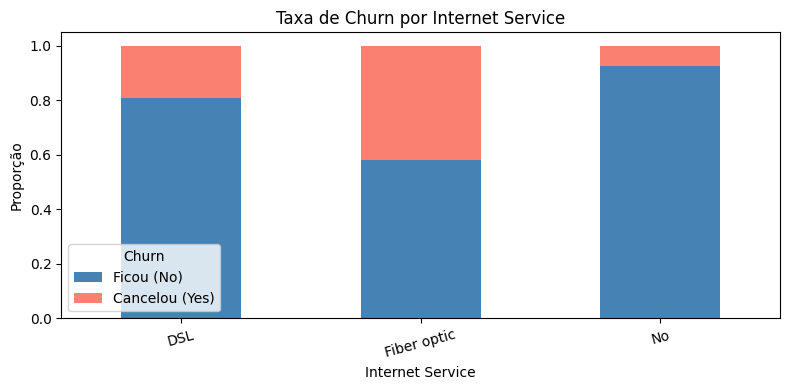

2026-04-17 22:59:47,115 INFO — Churn por Internet Service:
Churn Label         No   Yes
Internet Service            
DSL               81.0  19.0
Fiber optic       58.1  41.9
No                92.6   7.4


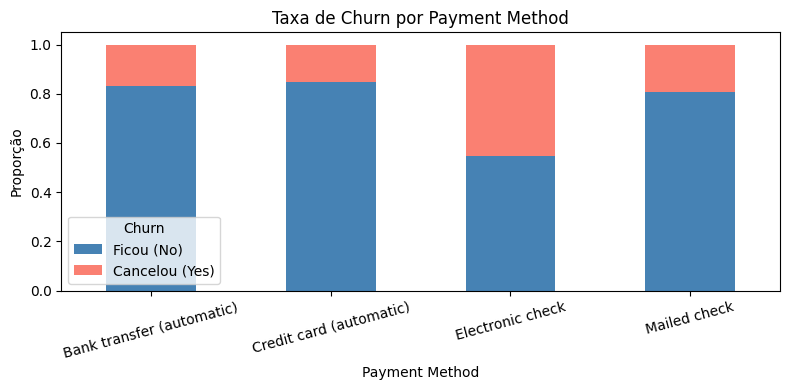

2026-04-17 22:59:47,233 INFO — Churn por Payment Method:
Churn Label                  No   Yes
Payment Method                       
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1


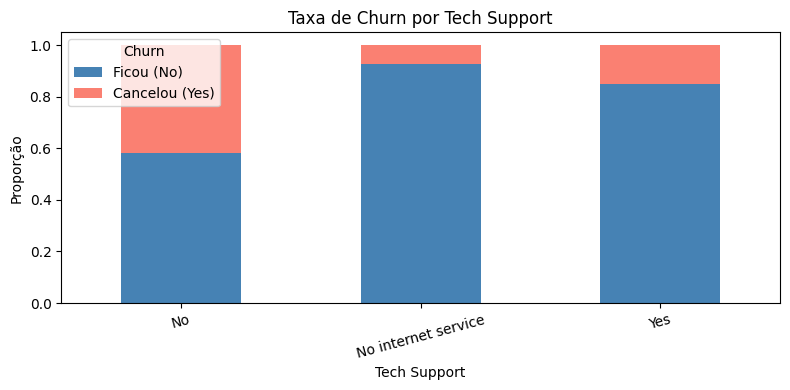

2026-04-17 22:59:47,340 INFO — Churn por Tech Support:
Churn Label            No   Yes
Tech Support                   
No                   58.4  41.6
No internet service  92.6   7.4
Yes                  84.8  15.2


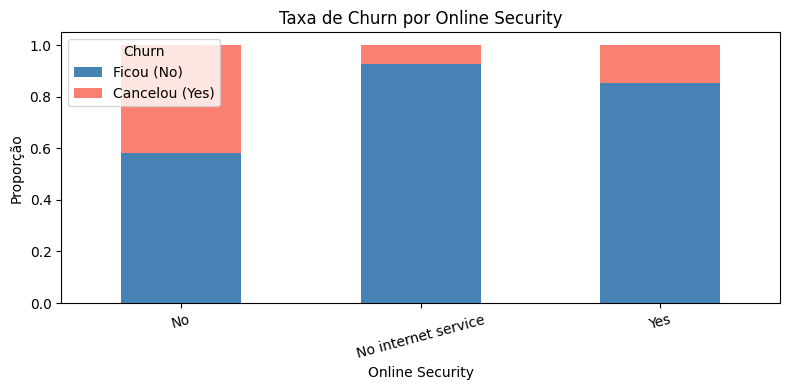

2026-04-17 22:59:47,451 INFO — Churn por Online Security:
Churn Label            No   Yes
Online Security                
No                   58.2  41.8
No internet service  92.6   7.4
Yes                  85.4  14.6


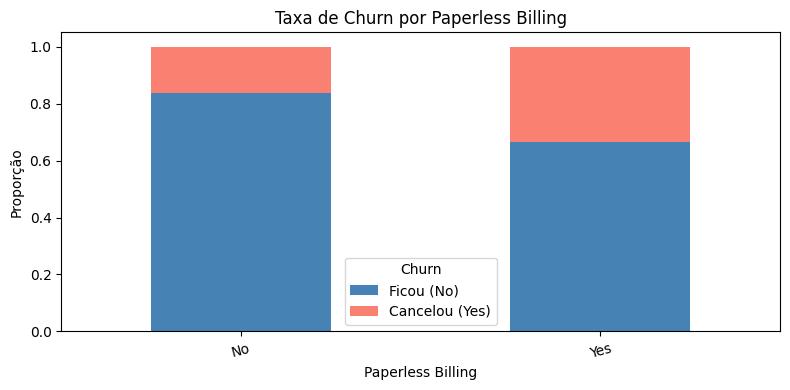

2026-04-17 22:59:47,554 INFO — Churn por Paperless Billing:
Churn Label          No   Yes
Paperless Billing            
No                 83.7  16.3
Yes                66.4  33.6


In [12]:
categoricas = ['Internet Service', 'Payment Method', 'Tech Support', 'Online Security', 'Paperless Billing']

for col in categoricas:
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index')
    ct.plot(kind='bar', stacked=True, color=['steelblue', 'salmon'], figsize=(8, 4))
    plt.title(f'Taxa de Churn por {col}')
    plt.ylabel('Proporção')
    plt.xticks(rotation=15)
    plt.legend(title='Churn', labels=['Ficou (No)', 'Cancelou (Yes)'])
    plt.tight_layout()
    plt.show()
    logger.info('Churn por %s:\n%s', col, (ct * 100).round(1).to_string())

### Resumo das Features Categóricas

| Feature | Grupo com MAIS churn | Taxa aprox. | Grupo com MENOS churn | Taxa aprox. |
|---|---|---|---|---|
| **Contract** | Month-to-month | ~43% | Two year | ~3% |
| **Internet Service** | Fiber optic | ~42% | No | ~7% |
| **Payment Method** | Electronic check | ~45% | Credit card (auto) | ~15% |
| **Tech Support** | No | ~42% | Yes | ~15% |
| **Online Security** | No | ~42% | Yes | ~14% |
| **Paperless Billing** | Yes | ~34% | No | ~17% |

**Todas essas features têm poder discriminatório — serão úteis para o modelo.**

---
## 6. Correlações entre Features Numéricas

2026-04-17 22:59:47,570 INFO — Correlação com Churn:
Tenure Months     -0.352229
Total Charges     -0.198324
Monthly Charges    0.193356
Churn_bin          1.000000


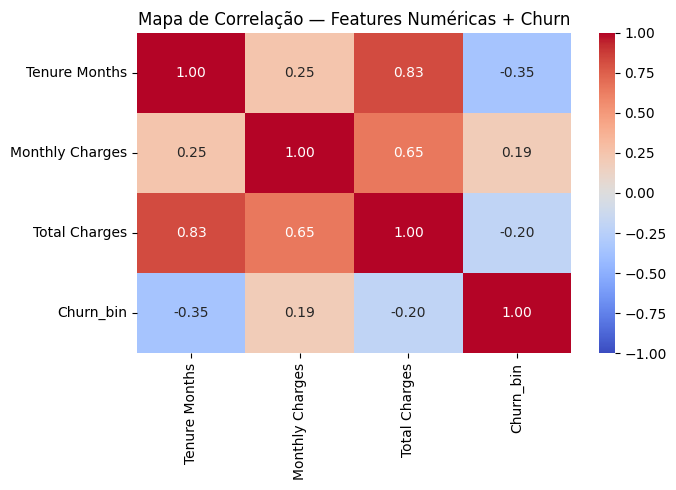

In [13]:
df_enc = df.copy()
df_enc['Churn_bin'] = (df_enc['Churn Label'] == 'Yes').astype(int)

corr = df_enc[num_cols + ['Churn_bin']].corr()
logger.info('Correlação com Churn:\n%s', corr['Churn_bin'].sort_values().to_string())

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Correlação — Features Numéricas + Churn')
plt.tight_layout()
plt.show()

**Observações:**
1. **`Tenure Months` × `Total Charges`**: correlação altíssima (~0.83) — total = tenure × mensalidade.
2. **`Tenure Months` × `Churn`**: correlação negativa (~-0.35) — mais tempo = menos churn ✓
3. **`Monthly Charges` × `Churn`**: correlação positiva (~+0.19) — mensalidade maior = mais churn ✓

> A alta correlação entre `Tenure Months` e `Total Charges` é multicolinearidade — redes neurais lidam bem com isso, mas modelos lineares podem ser afetados.

---
## 7. Identificação de Colunas para o Pipeline

In [14]:
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude',
    'Churn Score', 'CLTV', 'Churn Reason', 'Churn Value',
]

df_model = df.drop(columns=drop_cols + ['Churn Label'])
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols_model = df_model.select_dtypes(include=np.number).columns.tolist()

logger.info('Colunas a dropar: %s', drop_cols)
logger.info('Colunas categóricas (%d): %s', len(cat_cols), cat_cols)
logger.info('Colunas numéricas (%d): %s', len(num_cols_model), num_cols_model)

2026-04-17 22:59:47,718 INFO — Colunas a dropar: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Score', 'CLTV', 'Churn Reason', 'Churn Value']


2026-04-17 22:59:47,719 INFO — Colunas categóricas (16): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


2026-04-17 22:59:47,719 INFO — Colunas numéricas (3): ['Tenure Months', 'Monthly Charges', 'Total Charges']


---
## 8. Conclusões e Data Readiness

### 8.1 Resumo do Dataset

| Item | Valor |
|---|---|
| Total de registros | 7.043 clientes |
| Total de colunas | 33 features + 1 target (`Churn Label`) |
| Features numéricas (modelo) | 3 (`Tenure Months`, `Monthly Charges`, `Total Charges`) |
| Features categóricas (modelo) | 16 |
| Colunas removidas | 13 (IDs, geo, leakage) |

### 8.2 Problemas Encontrados e Decisões

| Problema | Decisão |
|---|---|
| `Monthly Charges` e `Total Charges` como `object` | Converter com `pd.to_numeric(..., errors='coerce')` |
| 11 valores `" "` em `Total Charges` (tenure=0) | Imputar com `0` |
| `Churn Reason` com 5.174 nulos | Remover — leakage (só existe após o churn) |
| `Churn Value`, `Churn Score`, `CLTV` | Remover — leakage ou derivados do target |

### 8.3 Features Mais Relevantes

| Posição | Feature | Tipo | Observação |
|---|---|---|---|
| 1 | `Contract` | Categórica | Maior discriminador: mensal = 43% vs 2 anos = 3% |
| 2 | `Tenure Months` | Numérica | Correlação -0.35 com churn |
| 3 | `Internet Service` | Categórica | Fibra = 42% vs sem internet = 7% |
| 4 | `Payment Method` | Categórica | Cheque eletrônico = 45% de churn |
| 5 | `Monthly Charges` | Numérica | Correlação +0.19 com churn |
| 6 | `Tech Support` | Categórica | Sem suporte = 42% vs com suporte = 15% |
| 7 | `Online Security` | Categórica | Sem segurança = 42% vs com segurança = 14% |

### 8.4 Próximos Passos

O pipeline em `src/preprocessing.py` deve:
1. Remover as colunas de leakage e identificadores
2. Converter `Monthly Charges` e `Total Charges` para numérico
3. Converter `Churn Label` para binário: Yes=1, No=0
4. Aplicar `OneHotEncoder` nas features categóricas
5. Aplicar `StandardScaler` nas features numéricas
6. Dividir em treino/teste estratificado por `Churn Label`

In [15]:
summary = {
    'shape': df.shape,
    'churn_rate_pct': round(float(churn_pct.get('Yes', churn_pct.iloc[0])), 2),
    'drop_cols': drop_cols,
    'cat_cols': cat_cols,
    'num_cols': num_cols_model,
}
for k, v in summary.items():
    logger.info('%s: %s', k, v)

2026-04-17 22:59:47,727 INFO — shape: (7043, 33)


2026-04-17 22:59:47,727 INFO — churn_rate_pct: 26.54


2026-04-17 22:59:47,728 INFO — drop_cols: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Score', 'CLTV', 'Churn Reason', 'Churn Value']


2026-04-17 22:59:47,728 INFO — cat_cols: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


2026-04-17 22:59:47,729 INFO — num_cols: ['Tenure Months', 'Monthly Charges', 'Total Charges']
